# 高级数据可视化

本教程将学习高级数据可视化技术，包括交互式图表和组合图表。

## 1. 导入必要的库

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 加载数据

In [13]:
# 加载天气数据
df = pd.read_csv('../data/weather_data.csv')
df['date'] = pd.to_datetime(df['date'])
print('数据形状:', df.shape)
print('数据预览:')
print(df.head())

数据形状: (20, 6)
数据预览:
        date city  temperature  humidity  wind_speed  precipitation
0 2024-01-01   北京            2        45          12              0
1 2024-01-01   上海            8        60           8              2
2 2024-01-01   广州           18        75           6              5
3 2024-01-01   深圳           19        72           7              3
4 2024-01-02   北京            0        50          15              0


## 3. 子图布局

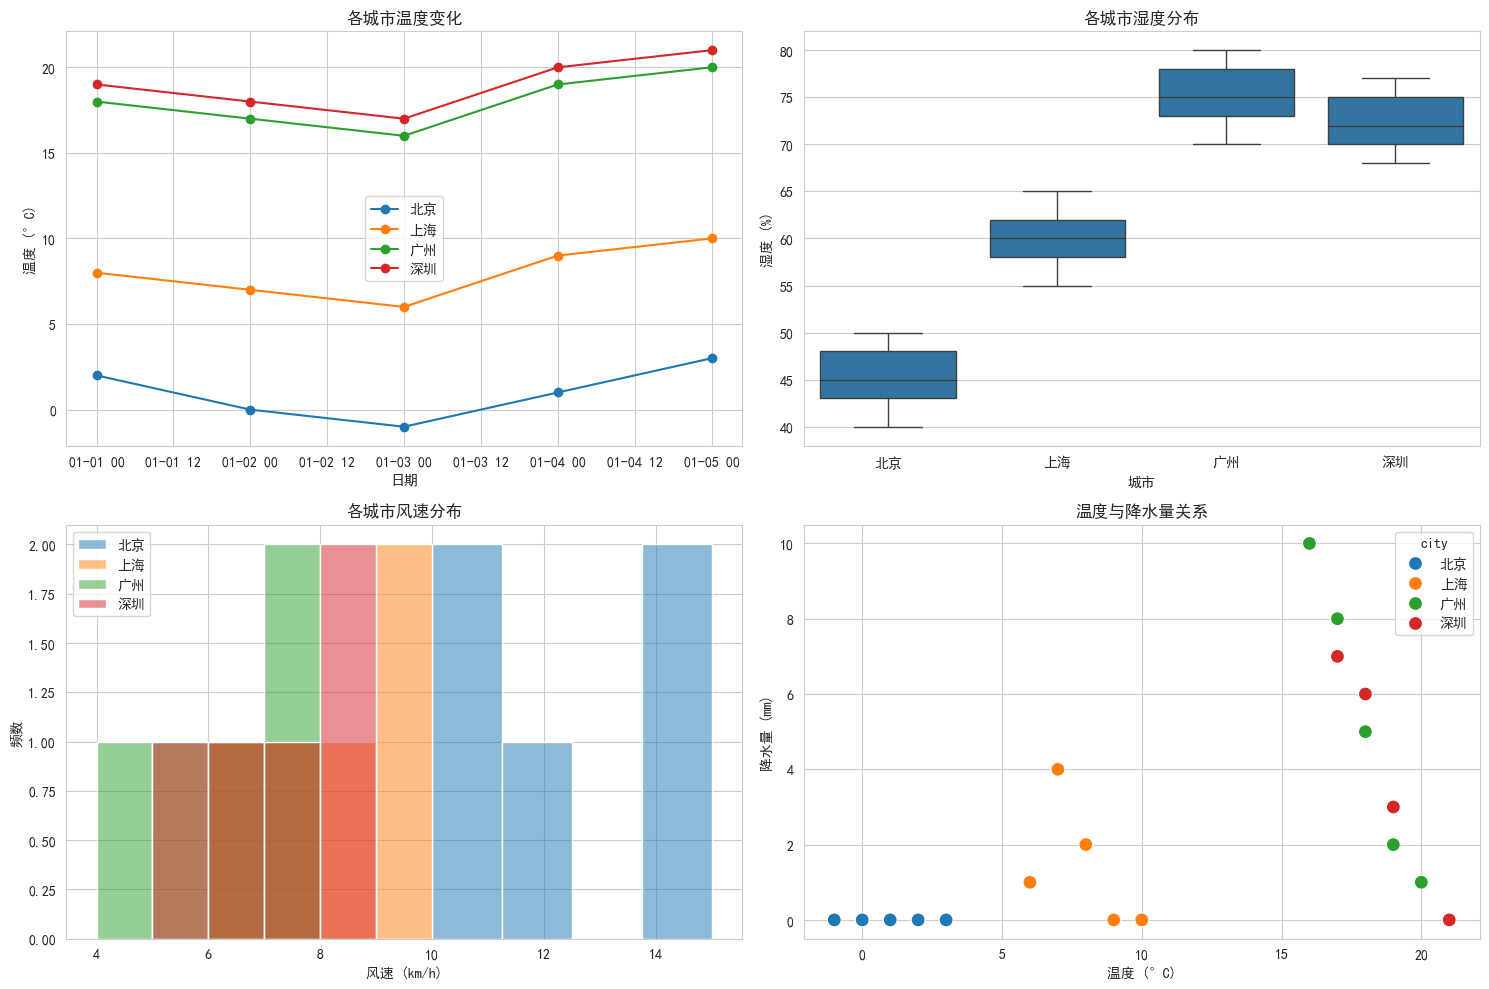

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 温度折线图
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    axes[0, 0].plot(city_data['date'], city_data['temperature'], marker='o', label=city)
axes[0, 0].set_title('各城市温度变化')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('温度 (°C)')
axes[0, 0].legend()

# 湿度箱线图
sns.boxplot(data=df, x='city', y='humidity', ax=axes[0, 1])
axes[0, 1].set_title('各城市湿度分布')
axes[0, 1].set_xlabel('城市')
axes[0, 1].set_ylabel('湿度 (%)')

# 风速直方图
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    sns.histplot(city_data['wind_speed'], ax=axes[1, 0], alpha=0.5, label=city)
axes[1, 0].set_title('各城市风速分布')
axes[1, 0].set_xlabel('风速 (km/h)')
axes[1, 0].set_ylabel('频数')
axes[1, 0].legend()

# 降水量散点图
sns.scatterplot(data=df, x='temperature', y='precipitation', hue='city', ax=axes[1, 1], s=100)
axes[1, 1].set_title('温度与降水量关系')
axes[1, 1].set_xlabel('温度 (°C)')
axes[1, 1].set_ylabel('降水量 (mm)')

plt.tight_layout()
plt.show()

## 4. 多变量可视化

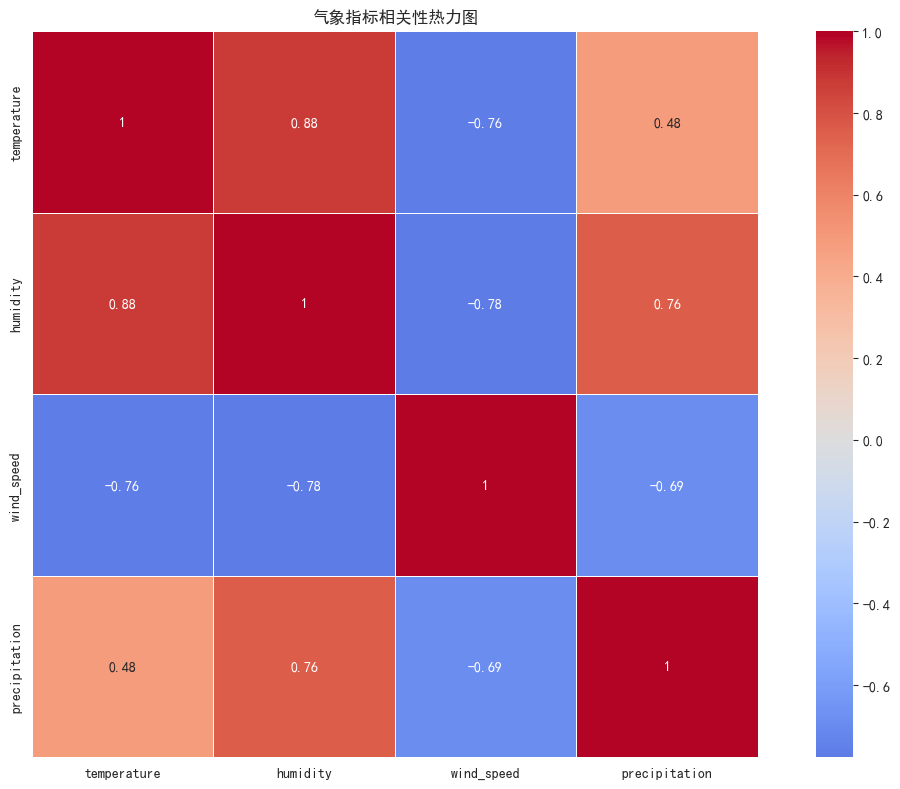

In [15]:
# 多变量相关性热力图
corr = df[['temperature', 'humidity', 'wind_speed', 'precipitation']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('气象指标相关性热力图')
plt.tight_layout()
plt.show()

## 5. 分组数据可视化

AttributeError: 'numpy.ndarray' object has no attribute 'set_xlabel'

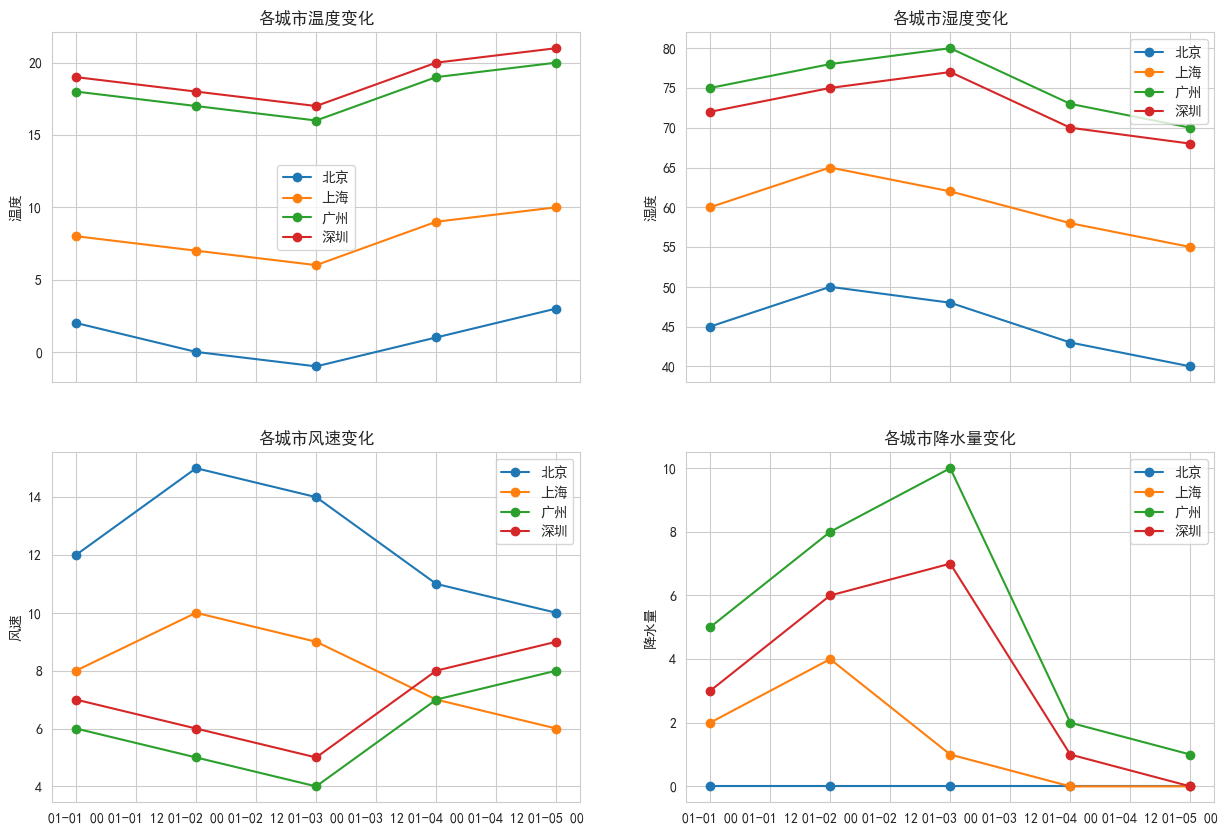

In [16]:
# 按城市分组的多指标可视化
# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

metrics = ['temperature', 'humidity', 'wind_speed', 'precipitation']
titles = ['温度', '湿度', '风速', '降水量']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row = i // 2
    col = i % 2
    for city in df['city'].unique():
        city_data = df[df['city'] == city]
        axes[row, col].plot(city_data['date'], city_data[metric], marker='o', label=city)
    axes[row, col].set_title(f'各城市{title}变化')
    axes[row, col].set_ylabel(title)
    axes[row, col].legend()

for ax in axes[:, :]:
    ax.set_xlabel('日期')

plt.tight_layout()
plt.show()

## 6. 面积图

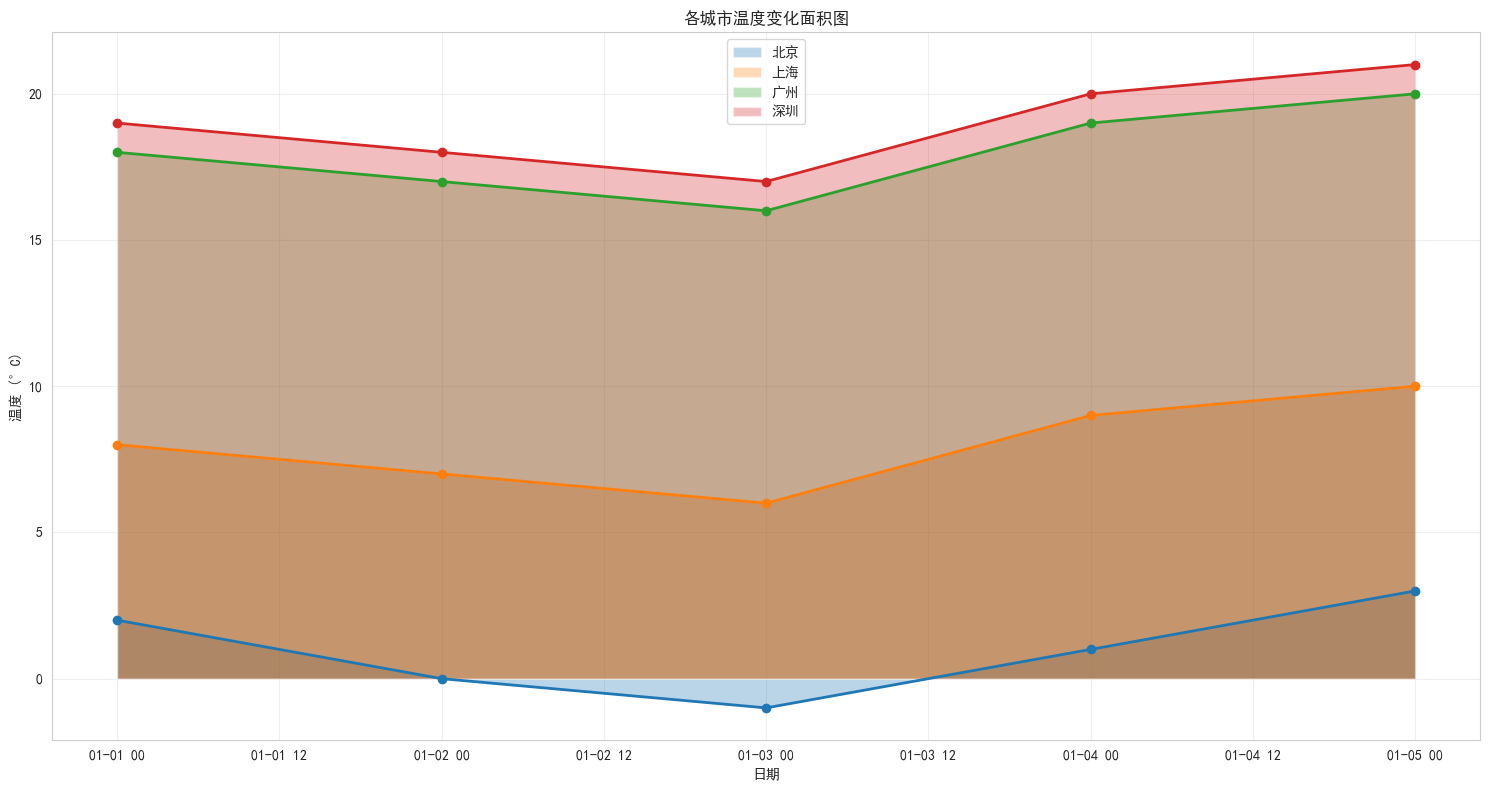

In [ ]:
# 面积图展示温度变化
plt.figure(figsize=(15, 8))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.fill_between(city_data['date'], city_data['temperature'], alpha=0.3, label=city)
    plt.plot(city_data['date'], city_data['temperature'], marker='o', linewidth=2)

plt.title('各城市温度变化面积图')
plt.xlabel('日期')
plt.ylabel('温度 (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 极坐标图

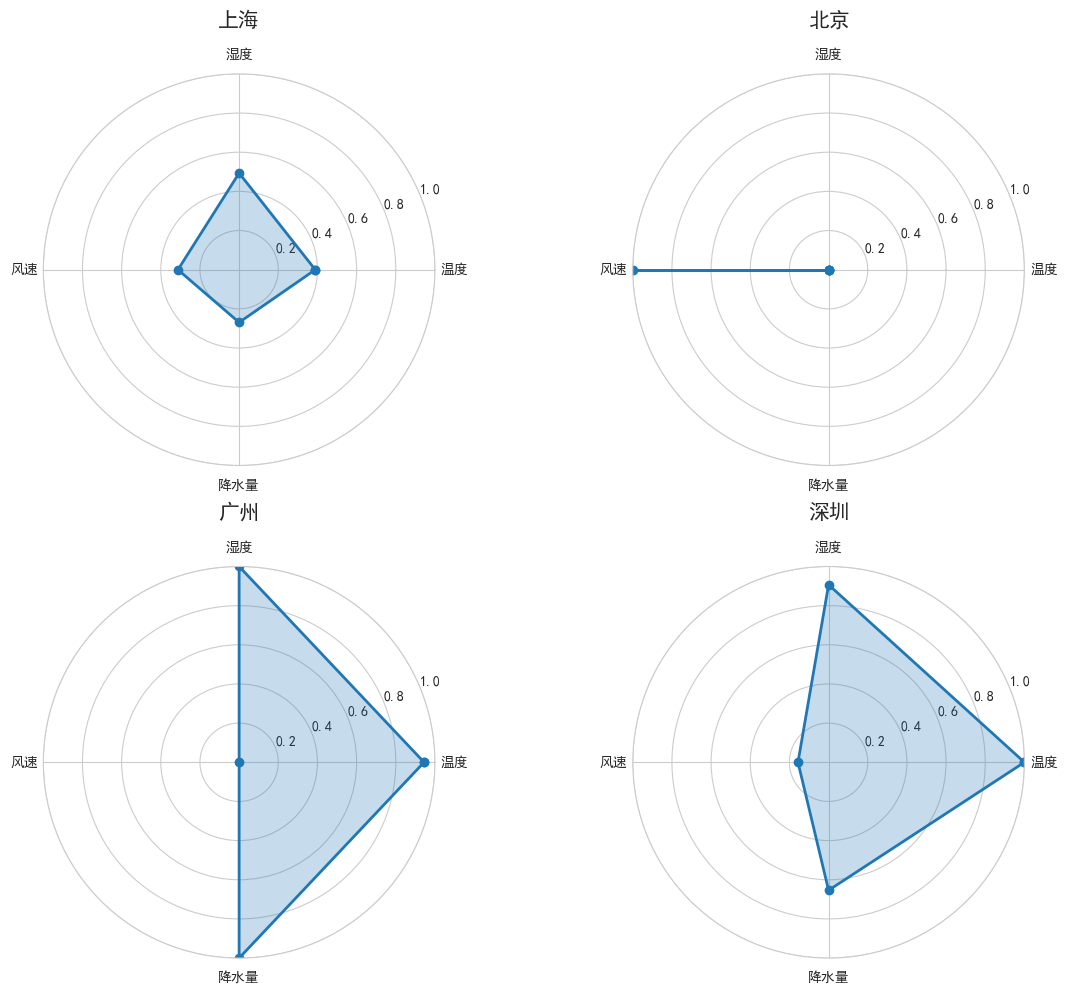

In [ ]:
# 极坐标图展示各城市气象指标
city_stats = df.groupby('city').mean().reset_index()

# 标准化数据
for col in ['temperature', 'humidity', 'wind_speed', 'precipitation']:
    city_stats[col + '_norm'] = (city_stats[col] - city_stats[col].min()) / (city_stats[col].max() - city_stats[col].min())

# 极坐标图
plt.figure(figsize=(12, 10))

# 设置角度
angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]  # 闭合

metrics = ['temperature_norm', 'humidity_norm', 'wind_speed_norm', 'precipitation_norm']
labels = ['温度', '湿度', '风速', '降水量']

for i, city in enumerate(city_stats['city']):
    ax = plt.subplot(2, 2, i + 1, projection='polar')
    values = city_stats.loc[city_stats['city'] == city, metrics].values.flatten().tolist()
    values += values[:1]  # 闭合
    
    ax.plot(angles, values, 'o-', linewidth=2, label=city)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_title(city, size=15, y=1.1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. 自定义样式和主题

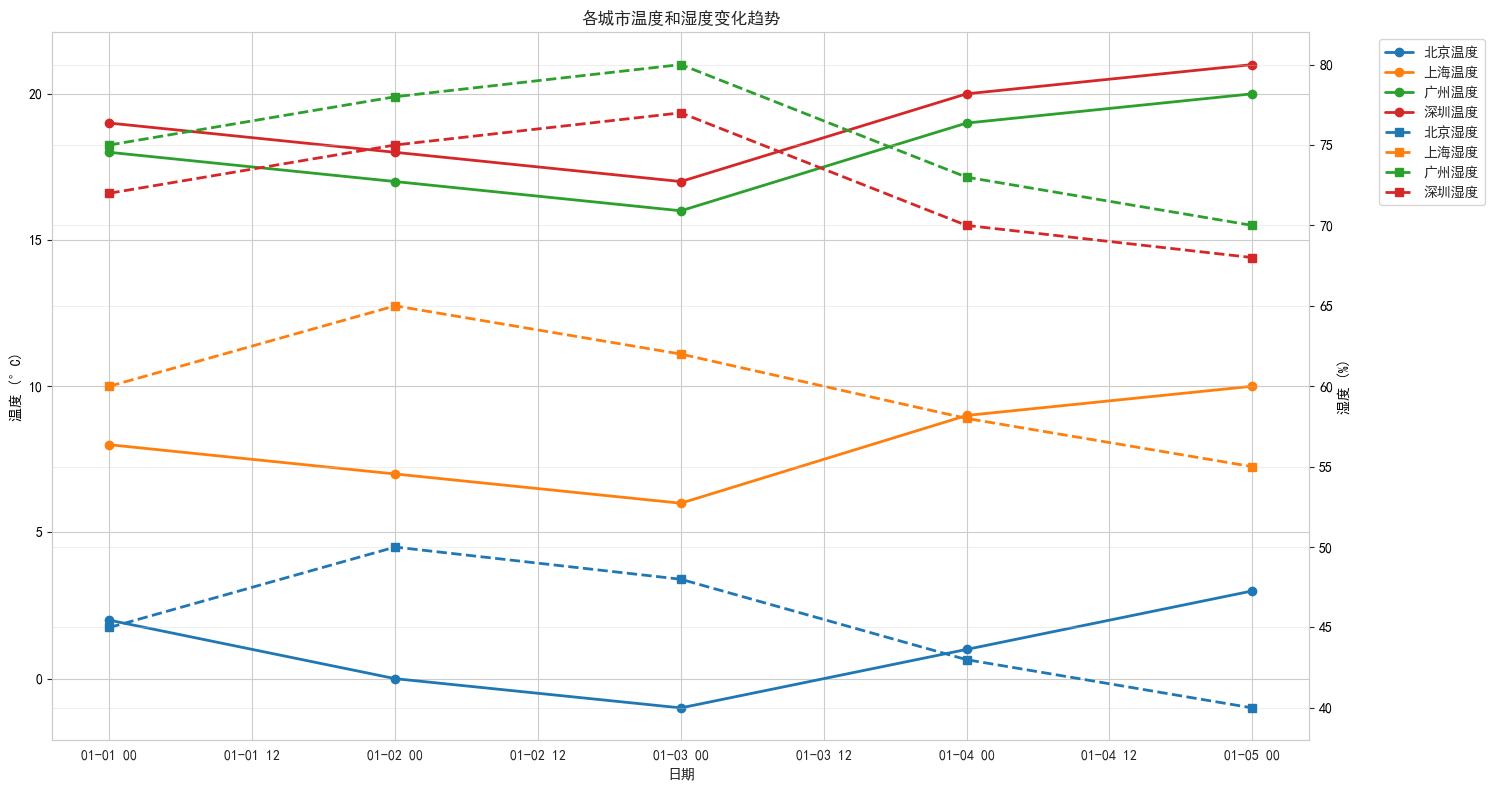

In [ ]:
# 自定义样式
# 设置自定义颜色
colors = {'北京': '#1f77b4', '上海': '#ff7f0e', '广州': '#2ca02c', '深圳': '#d62728'}

# 绘制多指标组合图
fig, ax1 = plt.subplots(figsize=(15, 8))

# 左侧y轴：温度
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    ax1.plot(city_data['date'], city_data['temperature'], marker='o', color=colors[city], linewidth=2, label=f'{city}温度')
ax1.set_xlabel('日期')
ax1.set_ylabel('温度 (°C)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 右侧y轴：湿度
ax2 = ax1.twinx()
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    ax2.plot(city_data['date'], city_data['humidity'], marker='s', color=colors[city], linestyle='--', linewidth=2, label=f'{city}湿度')
ax2.set_ylabel('湿度 (%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.title('各城市温度和湿度变化趋势')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()